In [1]:
import sys
sys.path.insert(0, '..')

import torch
import matplotlib.pyplot as plt
from src.shared.dataset import CelebAHQDataset
from src.shared.mask import generate_mask, apply_mask
from src.reconstruction.model import UNetInpainting

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = UNetInpainting().to(device)
model.load_state_dict(torch.load('../models/reconstruction_best.pth', map_location=device))
model.eval()

dataset = CelebAHQDataset('../data/celeba_hq_256')
print(f"Dataset size: {len(dataset)}")

Dataset size: 30000


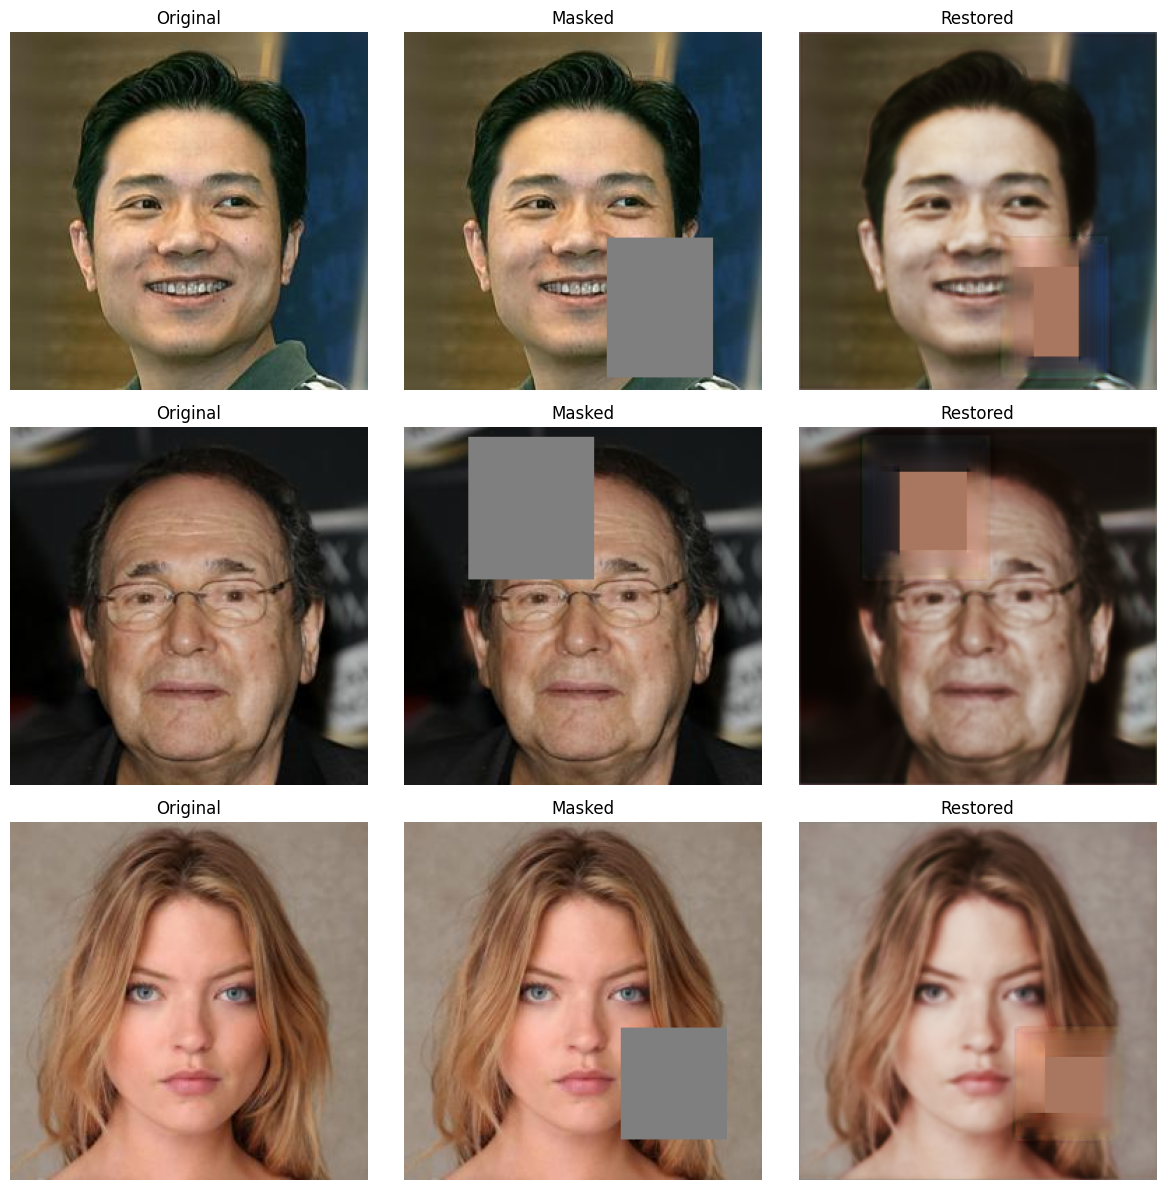

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    x = dataset[i].unsqueeze(0).to(device)
    mask = generate_mask(256, 256, condition='medium').unsqueeze(0).to(device)
    y = x * (1 - mask)

    with torch.no_grad():
        x_hat = model(y, mask)

    def to_img(t):
        return (t.squeeze().permute(1,2,0).cpu().numpy() * 0.5 + 0.5).clip(0,1)

    axes[i][0].imshow(to_img(x));    axes[i][0].set_title('Original');  axes[i][0].axis('off')
    axes[i][1].imshow(to_img(y));    axes[i][1].set_title('Masked');    axes[i][1].axis('off')
    axes[i][2].imshow(to_img(x_hat));axes[i][2].set_title('Restored'); axes[i][2].axis('off')

plt.tight_layout()
plt.savefig('../results/reconstruction_results.png', dpi=150)
plt.show()